# Background-derived control modes

Fit DMD to a spectral-infill background-only record, treat its feasible recovered modes as a control suite, and evaluate their subsequent recovery using the same figures and tables as the synthetic initial tests.

## Preamble

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import os
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

cwd = Path(os.getcwd()).resolve()
PROJECT_ROOT = next(
    path for path in (cwd, *cwd.parents)
    if (path / 'src' / 'msc_thesis').is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

## Configuration

The selected control configuration is Hankel $d=6$, no SVD rank truncation, and $n_{\max}=9$. A feasible background mode has a finite period strictly between 3 and 100 years; no quality-factor constraint is applied.

In [21]:
chosen_nmax = 9
chosen_svd_rank = 0.999
chosen_embedding_d = 4
n_ensemble = 50
control_period_limits = (3, 100)
background_seed = 42

chosen_dmd_settings = {
    'dmd_type': 'exact',
    'hankel_flag': True,
    'embedding_d': chosen_embedding_d,
    'weight_flag': True,
}

## Construct the background-derived control suite

In [22]:
gnm_chaos = CHAOS_Full_SV_Record_Obtain(nmax=chosen_nmax)
gnm_background = Non_Wave_Spectral_Infill(
    gnm_chaos,
    np.zeros_like(gnm_chaos),
    nmax=chosen_nmax,
    dt_sample=dt_sample,
    seed=background_seed,
)

A_control_r = Truncate_Gauss_Coeffs(A_15_r, tmax=chosen_nmax)
gnm_background_control = Truncate_Gauss_Coeffs(
    gnm_background,
    tmax=chosen_nmax,
)
background_record = A_control_r @ gnm_background_control.T

background_dmd_modes = Run_DMD(
    background_record,
    times_used_relative,
    svd_rank=chosen_svd_rank,
    dmd_settings=chosen_dmd_settings.copy(),
)
background_periods = np.asarray(background_dmd_modes['periods'], dtype=float)
period_min, period_max = control_period_limits
feasible_control_mask = (
    np.isfinite(background_periods)
    & (background_periods > period_min)
    & (background_periods < period_max)
)
feasible_control_indices = np.flatnonzero(feasible_control_mask)
feasible_control_indices = feasible_control_indices[
    np.argsort(background_periods[feasible_control_indices])
]

control_cmap = plt.get_cmap('viridis')
control_colours = control_cmap(
    np.linspace(0.10, 0.90, len(feasible_control_indices))
)
control_modes = {}
for control_number, (mode_index, mode_colour) in enumerate(
    zip(feasible_control_indices, control_colours),
    start=1,
):
    control_period = float(background_periods[mode_index])
    control_modes[f'C{control_number}'] = {
        'phasor': np.asarray(
            background_dmd_modes['phasors'][mode_index],
            dtype=complex,
        ),
        'eigenvalue': complex(
            background_dmd_modes['continuous_eigenvalues'][mode_index]
        ),
        'period': control_period,
        'true_period': control_period,
        'colour': mode_colour,
    }

print(f'Feasible control modes: {len(control_modes)}')
for control_key, control_info in control_modes.items():
    print(f"  {control_key}: {control_info['period']:.2f} years")

Feasible control modes: 6
  C1: 4.68 years
  C2: 5.58 years
  C3: 7.18 years
  C4: 10.58 years
  C5: 15.55 years
  C6: 33.63 years


/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 202104.89076618268. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:641: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)


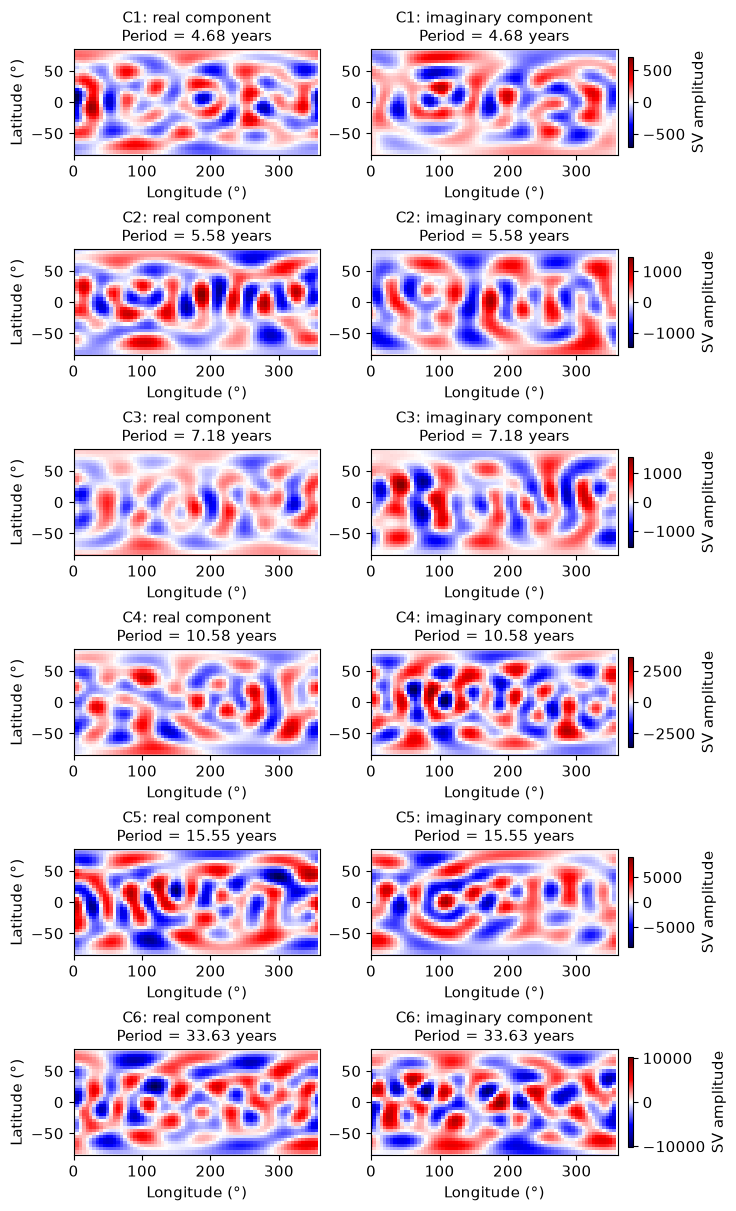

In [23]:
control_figure, control_axes = Plot_Mode_Phasors(
    control_modes,
    nmax=chosen_nmax,
    figure_width=text_width,
)
plt.show()

## Rank–degree recovery heatmap

The degree sweep stops at the selected $n_{\max}=9$. The red dashed cell identifies the chosen untruncated-rank configuration.

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 443577.5819893842. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1404: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1592: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 282033.4748614112. Consider p

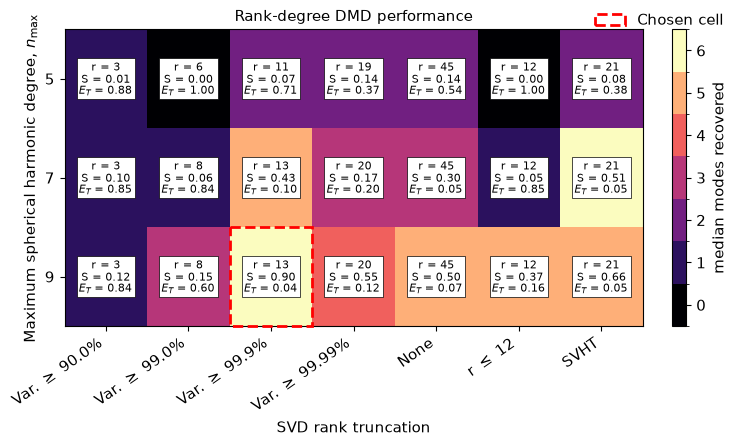

In [24]:
nmax_list = [5, 7, 9]
svd_rank_list = [
    0.9, 0.99, 0.999, 0.9999,
    -1, 2 * len(control_modes), 0,
]
heatmap_ensemble_settings = {
    'ensemble_flag': True,
    'n_ensemble': n_ensemble,
    'record_for_ensemble': 'control',
}

heatmap_figure, heatmap_axis, heatmap_colourbar = Rank_Degree_Heatmap(
    {'control': gnm_background},
    control_modes,
    nmax_list,
    svd_rank_list,
    chosen_dmd_settings.copy(),
    heatmap_ensemble_settings,
    syn_record=False,
    chosen_rank_degree=(chosen_svd_rank, chosen_nmax),
)

## Chosen control recovery and uncertainty ensemble

In [25]:
chosen_ensemble_settings = {
    'ensemble_flag': True,
    'n_ensemble': n_ensemble,
    'record_for_ensemble': 'control',
}
control_results, total_unmatched_periods, recovered_control_modes = (
    Pipeline_Run(
        {'control': gnm_background},
        control_modes,
        chosen_dmd_settings.copy(),
        nmax=chosen_nmax,
        svd_rank=chosen_svd_rank,
        ensemble_settings=chosen_ensemble_settings,
        syn_record=False,
        total_unmatched_period_return=True,
    )
)
control_results = Ensemble_To_Median(control_results, control_modes)
control_similarity_threshold = similarity_thresholds[
    'full_match'
][str(chosen_nmax)]

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 202104.89076618268. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:641: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1404: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)


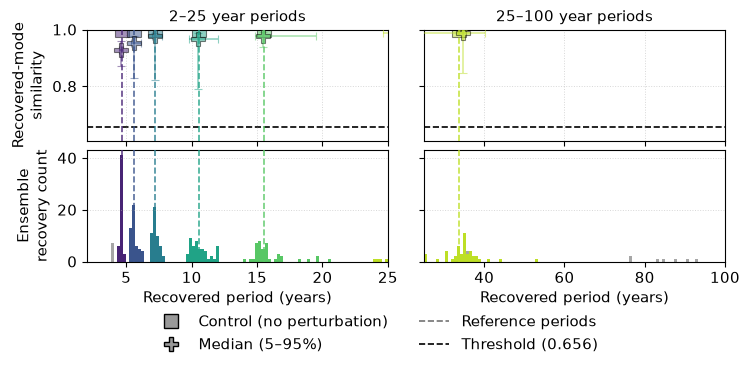

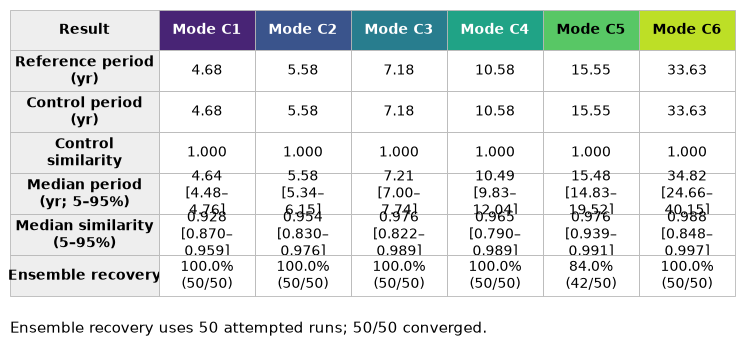

In [26]:
recovery_figure, recovery_axes = Plot_Single_Run_Ensemble_Results(
    control_results,
    control_modes,
    total_unmatched_periods,
    control_similarity_threshold,
    record_markers,
    record_plotting_params,
    figure_width=text_width,
    non_perturbed_record='control',
)

summary_figure, summary_table = Single_Run_Ensemble_Results_Table(
    control_results,
    control_modes,
    non_perturbed_record='control',
    ensemble_percentage_basis='attempted',
    figure_width=text_width,
)
plt.show()

## Background similarity-threshold calculation

For each degree from 1 through 9, both members of every control–synthetic comparison are truncated to that same degree and projected with the same design matrix. The stored metric is the maximum spatial similarity over all feasible control modes and all 62 synthetic database modes.

In [27]:
degree_list = np.arange(1, chosen_nmax + 1)
synthetic_mode_numbers = [str(mode_number) for mode_number in range(1, 63)]
synthetic_gauss_phasors = {
    mode_number: np.asarray(Component_Load_SV(mode_number)['gnm'])
    for mode_number in synthetic_mode_numbers
}
control_gauss_phasors = {
    control_key: Grid_Phasor_To_Gauss(
        control_info['phasor'],
        design_matrix=A_control_r,
        spatial_weights=W2D.ravel(),
    )
    for control_key, control_info in control_modes.items()
}

correlation_match_metric = {'background': {}}
for degree in degree_list:
    degree_key = str(degree)
    A_degree_r = Truncate_Gauss_Coeffs(A_15_r, tmax=degree)
    degree_similarities = []

    for control_gauss_phasor in control_gauss_phasors.values():
        control_gauss_degree = Truncate_Gauss_Coeffs(
            control_gauss_phasor,
            tmax=degree,
        )
        control_grid_degree = A_degree_r @ control_gauss_degree

        for synthetic_gauss_phasor in synthetic_gauss_phasors.values():
            synthetic_gauss_degree = Truncate_Gauss_Coeffs(
                synthetic_gauss_phasor,
                tmax=degree,
            )
            synthetic_grid_degree = A_degree_r @ synthetic_gauss_degree
            degree_similarities.append(
                Complex_Phasor_Compare(
                    synthetic_grid_degree,
                    control_grid_degree,
                )
            )

    correlation_match_metric['background'][degree_key] = float(
        np.max(degree_similarities)
    )

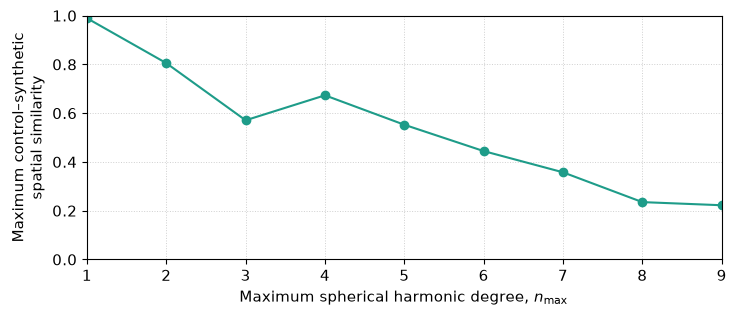

In [28]:
background_similarity_thresholds = np.asarray([
    correlation_match_metric['background'][str(degree)]
    for degree in degree_list
])
fig, ax = plt.subplots(
    figsize=(text_width, 0.42 * text_width),
    constrained_layout=True,
)
ax.plot(
    degree_list,
    background_similarity_thresholds,
    color=control_cmap(0.55),
    marker='o',
)
ax.set(
    xlabel=r'Maximum spherical harmonic degree, $n_{\max}$',
    ylabel='Maximum control–synthetic\nspatial similarity',
    xlim=(1, chosen_nmax),
    ylim=(0, 1),
    xticks=degree_list,
)
ax.grid(True, linestyle=':', linewidth=0.7, alpha=0.6)
plt.show()

In [29]:
match_metrics_path = Path(FELIX_DIR) / 'match_metrics.pkl'
with open(match_metrics_path, 'rb') as metrics_file:
    match_metrics = pickle.load(metrics_file)
if not isinstance(match_metrics, dict):
    raise TypeError(
        f'Expected a dictionary, got {type(match_metrics).__name__}.'
    )

# Explicitly overwrite the background entry and the existing file.
match_metrics['background'] = correlation_match_metric['background']
with open(match_metrics_path, 'wb') as metrics_file:
    pickle.dump(
        match_metrics,
        metrics_file,
        protocol=pickle.HIGHEST_PROTOCOL,
    )
print(f'Updated background match metrics in: {match_metrics_path}')

Updated background match metrics in: /home/elliott/projects/msc_thesis_project/data/modes_surface/match_metrics.pkl
